In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
from sympy.abc import sigma

from pi_solvers.utils import gaussians
from pi_solvers import sde_lib, solver_lib

torch.manual_seed(42)

In [2]:
# SDE Setup
beta_min = 0.1
beta_max = 20
sde = sde_lib.LinearVariancePreservingSDE(beta_min, beta_max)

In [128]:
# Gaussian & score setup
n = 10
mu_std = 5
mus = torch.linspace(-n, n, n)
sigmas = torch.zeros(n) + 0.3 
weights = torch.ones(n) / n

gaussians_ = []
for i in range(n):
    gaussians_.append(gaussians.Gaussian(mu=mus[i], sigma=sigmas[i], weight=weights[i]))

"""gaussian1 = gaussians.Gaussian(
    mu=0,
    sigma=1,
    weight=1/8
)
gaussian2 = gaussians.Gaussian(
    mu=-50,
    sigma=3,
    weight=2/8
)

gaussian3 = gaussians.Gaussian(
    mu=15,
    sigma=5,
    weight=1/2
)

gaussian4 = gaussians.Gaussian(
    mu=-20,
    sigma=10,
    weight= 1/8
)"""

multi_gaussian = gaussians.MultiGaussian(tuple(gaussians_), sde)
score_func = multi_gaussian.get_score_function()

# Create reverse sde_lib based on score function
reverse_sde = sde.get_reverse_sde(score_func)

Text(0.5, 0, 'x')

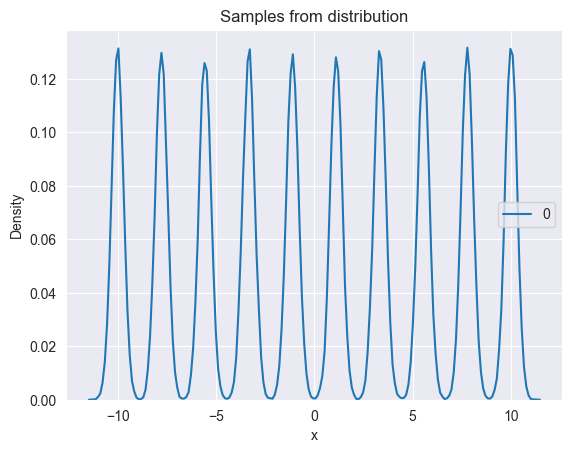

In [129]:
# Sampling
n_samples = 100000
samples = multi_gaussian.sample(n_samples).unsqueeze(-1)
x_ground_truth = torch.sort(samples)[0]

plt.figure()
sns.kdeplot(x_ground_truth, bw_adjust=0.1)
plt.title("Samples from distribution")
plt.xlabel("x")

Text(0.5, 0, 'x')

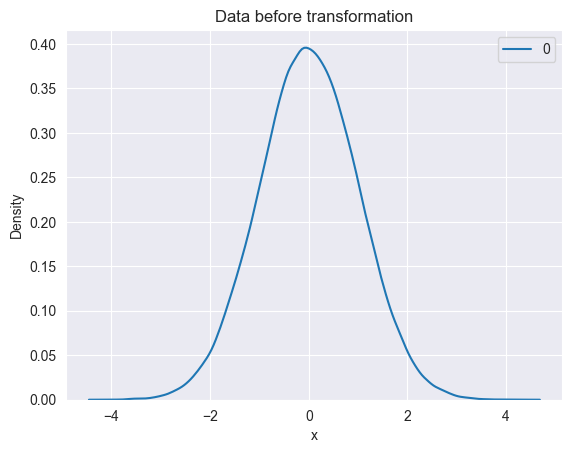

In [130]:
# Sample x from the marginal
x_start = sde.sample(x_ground_truth, torch.Tensor([1]))

# Plot initial data
plt.figure()
sns.kdeplot(x_start)
plt.title("Data before transformation")
plt.xlabel("x")

In [131]:
# Euler Marayuma setup
multi_gaussian.reset_nfe()

x_em_log = []
t_em_log = []

def log_em(x: torch.Tensor, t: torch.Tensor):
    # Track 4 x from the batch
    x_em_log.append(x[0:4, :].clone())
    t_em_log.append(t.clone())

n_steps = 30
discretisation = torch.linspace(1, 0, n_steps)
em_solver = solver_lib.EulerMarayumaSolver(reverse_sde, discretisation)

x_em = em_solver.solve(x_start.clone(), callback=log_em)

# Logging
x_em_log = np.array(x_em_log)[:, :, 0]
t_em_log = np.array(t_em_log)

# Baseline PDF
interval = torch.linspace(torch.min(x_em) - 3, torch.max(x_em) + 3, 10000).unsqueeze(-1)
verification = multi_gaussian(interval)

x tensor(False)
non_normalised tensor(False)
normalisation tensor(2.7122e-05) tensor(0.3986)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(2.0896e-05) tensor(0.3983)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(5.7293e-06) tensor(0.3977)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(3.0696e-06) tensor(0.3966)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(8.9465e-06) tensor(0.3946)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.3304e-05) tensor(0.3912)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(5.0432e-06) tensor(0.3856)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.6212e-06) tensor(0.3766)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(4.8099e-06) tensor(0.3629)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.3353e-05) tensor(0.3429)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(3.43

Text(0.5, 0, 'x')

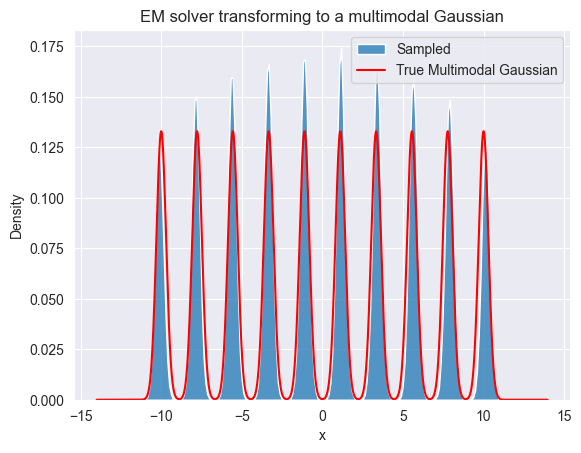

In [132]:
# Euler Marayuma Plots
plt.figure()
sns.kdeplot(x_em, label="Sampled", multiple="stack", bw_adjust=0.1)
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("EM solver transforming to a multimodal Gaussian")
plt.xlabel("x")

In [133]:
# Euler Marayuma Evaluation
nfe_em_per_sample = multi_gaussian.nfe / n_samples
wasserstein_distance_em = scipy.stats.wasserstein_distance(x_ground_truth[:, 0], torch.sort(x_em)[0][:, 0])

print(f"NFE per sample for Euler-Marayuma sampler: {nfe_em_per_sample}")
print(f"Wasserstein distance for Euler-Marayuma sampler: {wasserstein_distance_em}")

NFE per sample for Euler-Marayuma sampler: 29.0
Wasserstein distance for Euler-Marayuma sampler: 0.2751598409309238


In [134]:
# PI solver setup
reverse_sde.reset()
torch.manual_seed(42)

x_pi_log = []
t_pi_log = []

def log_pi(x: torch.Tensor, t: torch.Tensor, error, **kwargs):
    # Track 4 x from the batch
    x_pi_log.append(x[0:4, :].clone())
    t_pi_log.append(t[0:4, :].clone())
    print(t.mean(), error.mean())


pi_solver = solver_lib.PISolver(
    reverse_sde,
    ki=0.101, 
    kp=0.09, 
    tau_a=0.7, 
    tau_r=0,
    alpha=0.8,
    h_start=0.01,
    max_decrease=0.2,
    max_increase=5,
    seed=5
)

x_pi = pi_solver.solve(x_start.clone(), callback=log_pi)

# Logging
x_pi_log = np.array(x_pi_log)[:, :, 0]
t_pi_log = np.array(t_pi_log)[:, :, 0]

# Baseline PDF
interval = torch.linspace(torch.min(x_pi) - 3, torch.max(x_pi) + 3, 10000).reshape((10000, 1))
verification = multi_gaussian(interval)

x tensor(False)
non_normalised tensor(False)
normalisation tensor(2.7122e-05) tensor(0.3986)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.0251e-05) tensor(0.3985)
tensor(0.9900) tensor(0.0272)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.0872e-05) tensor(0.3985)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(5.5258e-05) tensor(0.3984)
tensor(0.9703) tensor(0.0772)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(5.0723e-05) tensor(0.3984)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(4.5453e-06) tensor(0.3982)
tensor(0.9471) tensor(0.0956)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(8.7293e-06) tensor(0.3982)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(2.4510e-05) tensor(0.3979)
tensor(0.9186) tensor(0.1259)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(3.7898e-05) tensor(0.3980)
x tensor(False)
non_normalised tensor(False

Text(0.5, 0, 'x')

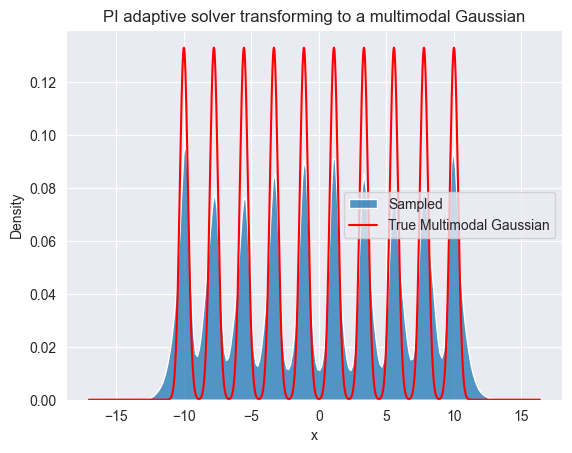

In [135]:
# PI Plots
plt.figure()
sns.kdeplot(x_pi, label="Sampled", multiple="stack", bw_adjust=0.3)
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("PI adaptive solver transforming to a multimodal Gaussian")
plt.xlabel("x")

In [136]:
# PI Evaluation
nfe_pi_per_sample = reverse_sde.nfe / x_start.shape[0]
wasserstein_distance_pi = scipy.stats.wasserstein_distance(x_ground_truth[:, 0], torch.sort(x_pi)[0][:, 0])

print(f"NFE per sample for PI sampler: {nfe_pi_per_sample}")
print(f"Wasserstein distance for PI sampler: {wasserstein_distance_pi}")

NFE per sample for PI sampler: 35.70388
Wasserstein distance for PI sampler: 0.25338047395234936


In [104]:
# GFF solver setup
reverse_sde.reset()
torch.manual_seed(42)


def log_gff(x: torch.Tensor, t: torch.Tensor, h, error):
    # Track 4 x from the batch
    print(torch.mean(t), torch.mean(h), torch.mean(error))


gff_solver = solver_lib.GottaGoFast(
    reverse_sde,
    tau_a=1e-7,
    tau_r=0.3,
    alpha=0.9,
    h_start=0.001,
    r=0.1,
)

x_gff = gff_solver.solve(x_start.clone(), callback=log_gff)


# Baseline PDF
interval = torch.linspace(torch.min(x_gff) - 3, torch.max(x_gff) + 3, 10000).reshape((10000, 1))
verification = multi_gaussian(interval)

x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.5359e-05) tensor(0.3982)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.6528e-05) tensor(0.3982)
tensor(0.9990) tensor(-0.0032) tensor(5.0044e-05)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.6528e-05) tensor(0.3982)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.2050e-05) tensor(0.3982)
tensor(0.9958) tensor(-0.0073) tensor(0.0006)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.2050e-05) tensor(0.3982)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(2.8148e-05) tensor(0.3981)
tensor(0.9885) tensor(-0.0133) tensor(0.0051)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(2.8148e-05) tensor(0.3981)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.8310e-07) tensor(0.3981)
tensor(0.9753) tensor(-0.0202) tensor(0.0263)
x tensor(False)
non_normalised tensor(False)
normalisation tensor(1.

Text(0.5, 0, 'x')

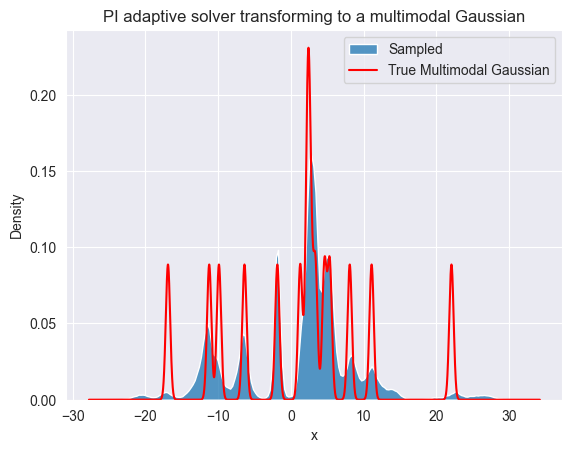

In [105]:
# GFF Plots
plt.figure()
sns.kdeplot(x_gff, label="Sampled", multiple="stack", bw_adjust=0.2)
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("PI adaptive solver transforming to a multimodal Gaussian")
plt.xlabel("x")

In [106]:
# GFF Evaluation
nfe_gff_per_sample = reverse_sde.nfe / x_start.shape[0]
wasserstein_distance_gff = scipy.stats.wasserstein_distance(x_ground_truth[:, 0], torch.sort(x_gff)[0][:, 0])

print(f"NFE per sample for Gotta go Fast sampler: {nfe_gff_per_sample}")
print(f"Wasserstein distance for Gotta go Fast sampler: {wasserstein_distance_gff}")

NFE per sample for Gotta go Fast sampler: 37.94928
Wasserstein distance for Gotta go Fast sampler: 1.3034201954367386


In [15]:
df = pd.read_csv("gaussian_results/data-1775071551.0/data.csv")

plt.figure()
sns.scatterplot(df, x="em_nfe", y="em_error", label="Euler Marayuma Solver")
sns.scatterplot(df, x="pi_nfe", y="pi_error", label="Proportional Integral Solver")
plt.xlabel("NFE")
plt.xlim(0, 500)
plt.ylim(0, 2)
plt.ylabel("Error")
plt.title("NFE - Error trade off")
plt.legend()

FileNotFoundError: [Errno 2] No such file or directory: 'gaussian_results/data-1775071551.0/data.csv'

In [50]:
# Create probability density colour map
x_interval = torch.linspace(torch.min(x_pi) - 3, torch.max(x_pi) + 3, 300)
t_interval = torch.linspace(0, 1, 200)
X, T = torch.meshgrid(x_interval, t_interval)
C = torch.zeros(X.shape)

for i, t in enumerate(t_interval):
    C[:, i] = multi_gaussian.multigaussian_at_t(t)(x_interval)

C:\Users\ellak\PycharmProjects\proportial-integral-generative-sde-solvers\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


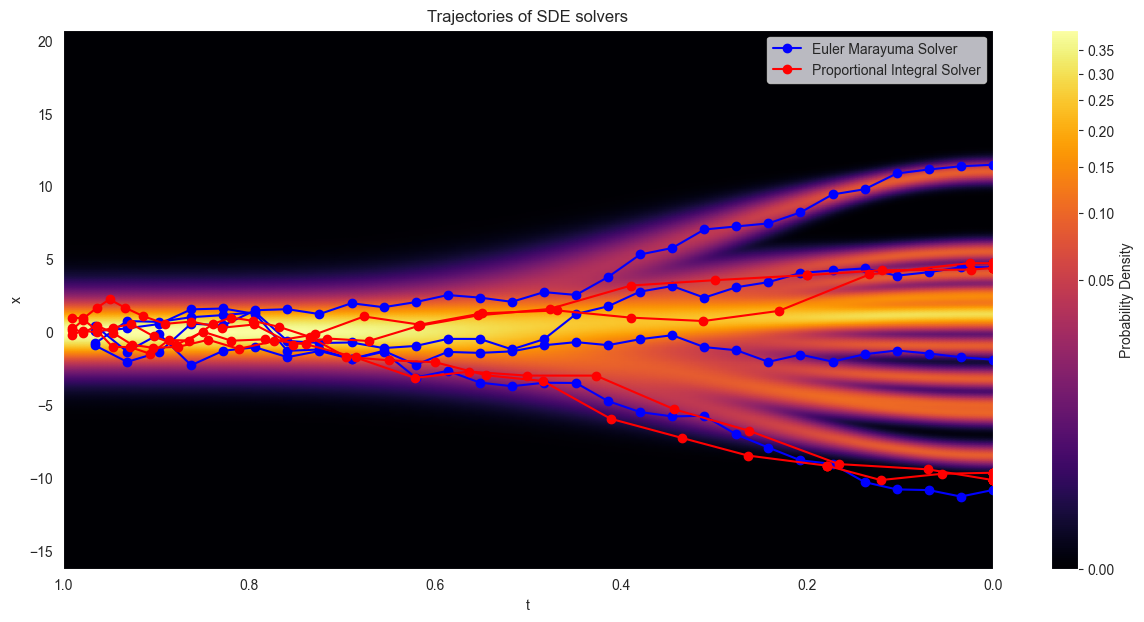

In [100]:
# Plotting
plt.figure(figsize=(15, 7))
plt.title("Trajectories of SDE solvers")

plt.xlim(1, 0)
mesh = plt.pcolormesh(T, X, C, cmap='inferno', shading='gouraud', norm=PowerNorm(gamma=0.3))
plt.colorbar(mesh,label='Probability Density')
for i in range(4):
    em = plt.plot(t_em_log[:, i, 0], x_em_log[:, i], 'bo-')
em[0].set_label("Euler Marayuma Solver")

for i in range(4):
    pi = plt.plot(t_pi_log[:, i], x_pi_log[:, i], 'ro-')
pi[0].set_label("Proportional Integral Solver")

plt.xlabel("t")
plt.ylabel("x")
plt.legend()
    
plt.show()